Loading CIFAR-10 data for Transfer Learning...
Loading pre-trained MobileNetV2 base model...


C:\Users\muham\AppData\Local\Temp\ipykernel_19452\1392808820.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Building the custom classifier on top...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training the Transfer Learning model... (This will be relatively fast)
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.2389 - loss: 2.0869 - val_accuracy: 0.2895 - val_loss: 1.9750
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.2674 - loss: 1.9994 - val_accuracy: 0.2978 - val_loss: 1.9443
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.2743 - loss: 1.9789 - val_accuracy: 0.3046 - val_loss: 1.9302
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.2788 - loss: 1.9647 - val_accuracy: 0.3069 - val_loss: 1.9184
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.2804 - loss: 1.9537 - val_accuracy: 0.3065 - val_loss: 1.9137
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.2854 - loss: 1.9443 - val_accuracy: 0.3029 - val_loss: 1.9082
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.2874 - loss: 1.9366 - val_accuracy: 0.3022 - val_loss: 1.9044
Epoch 8/10
625/625 

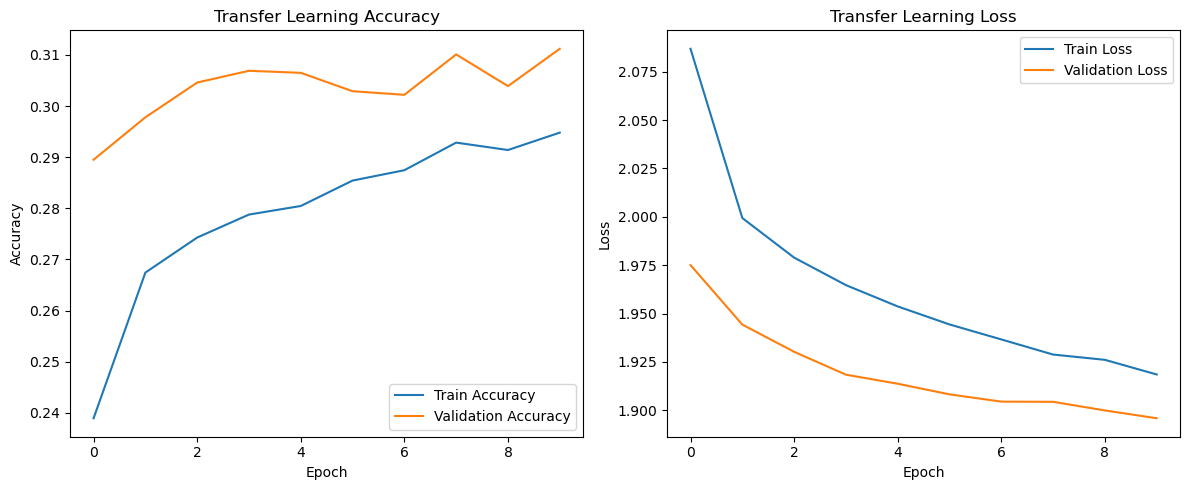

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess Data for MobileNetV2
print("Loading CIFAR-10 data for Transfer Learning...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# MobileNetV2 expects pixels in a specific range [-1, 1], 
# so we use its built-in preprocess_input function instead of simple division by 255.
x_train = preprocess_input(x_train_full.astype('float32'))
x_test = preprocess_input(x_test_full.astype('float32'))

y_train = y_train_full.flatten()
y_test = y_test_full.flatten()

# 2. Load the Pre-trained Modern CNN (MobileNetV2)
print("Loading pre-trained MobileNetV2 base model...")
# include_top=False means we drop the original ImageNet classifier
# weights='imagenet' downloads the pre-learned weights
base_model = MobileNetV2(input_shape=(32, 32, 3), 
                         include_top=False, 
                         weights='imagenet')

# FREEZE the base model so we don't destroy the pre-trained weights
base_model.trainable = False

# 3. Build the Transfer Learning Model
print("Building the custom classifier on top...")
model_tl = Sequential([
    Input(shape=(32, 32, 3)),
    base_model,
    GlobalAveragePooling2D(), # Converts 2D feature maps to 1D vector
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

# 4. Compile the model
model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model_tl.summary()

# 5. Train the model (Only the top custom layers will be trained)
print("Training the Transfer Learning model... (This will be relatively fast)")
history_tl = model_tl.fit(x_train, y_train, 
                          epochs=10, # 10 epochs are usually enough for Transfer Learning
                          batch_size=64, 
                          validation_split=0.2, 
                          verbose=1)

# 6. Evaluate on Test Data
print("\nEvaluating Transfer Learning model on test data...")
test_loss, test_acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f"Transfer Learning Test Accuracy: {test_acc:.4f}")

# 7. Plot Training and Validation Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()